# **Laboration 3 - Linjär klassificering**

###### <b>Patrik Hellgren<br>AIM25G<br>2025-10-03</b>

---

<span style="font-family: Calibri; font-size: 12pt">

### **Förord**
Denna rapport är ett komplement till filen *`laboration_3_multi.py`*. Koden i den filen importeras för att kunna visualisera vår data. Det finns även en tillhörande *`README.md`*-fil som beskriver hela programmets funktion.

I denna rapport kommer jag att diskutera tankar och resonemang kring de olika linjerna samt dess resultat och tillämpning.

### **Sammanfattning**
Laborationen handlar om att undersöka en linjär klassificering. En csv-fil med oklassificerade datapunkter (*`unlabelled_data.csv`*) läses in. Därefter dras en egen linje som separerar de båda klustren för att utefter den linjens placering kunna klassificera alla datapunkter som **0** eller **1** beroende på om de är under eller över linjen. Datapunkterna färgkodas (<font color="green">**0**</font>:or blir gröna och <font color="blue">**1**</font>:or blir blåa) och plottas sedan tillsammans med linjen.

När klassificeringen är gjord skrivs en ny csv-fil (*`labelled_data.csv`*) där både x- och y-värden samt klassificering för respektive punkt finns med.

Nu när vi har en funktion för att klassificera varje enskild datapunkt baserat på en linjes ekvation så gör vi detta även för tre andra linjer. Detta visualiseras i ytterligare plottar här i `report.ipynb`.

##### **Frågeställningar**
Efter att koden blev klar så började själva resonemanget kring de linjära klassificeringarna. Här dök det initialt upp ett par frågeställningar hos mig (med varierande betydelse ska tilläggas):

* *Vad innebär det att...*
    * ...alla linjer har i princip lika många 0:or och 1:or? Säger det något om valet av klassificeringsmodell?
    * ...endast en linje har k > 0 och därmed får motsatt klassificering på majoriteten av datapunkterna gentemot övriga linjer?
    * ...vissa punkter alltid får samma klassificering oavsett linje?
    * ...två av punkterna **inte** alltid är samma för alla linjer med k < 0?

</span>

<span style="font-family: Calibri; font-size: 12pt">

##### **Linjerna f(x), g(x) & h(x)**

I kodblocket här nedanför anropas funktionen `calculate_line_and_classify` på de tre linjerna nedan:

<code>
f(x) = −0.489x<br>
g(x) = −2x + 0.16<br>
h(x) = 800x − 120
</code>

Här skapas dels en NumPy ndarray med beräknade y-värden samt ett pandas Series-objekt med klassificeringarna för respektive punkt längs linjen.

</span>

In [3]:
from laboration_3_multi import calculate_line_and_classify, x, data

line_fx, labelled_data_fx = calculate_line_and_classify(-0.489, x, 0, data)
line_gx, labelled_data_gx = calculate_line_and_classify(-2, x, 0.16, data)
line_hx, labelled_data_hx = calculate_line_and_classify(800, x, -120, data)

<span style="font-family: Calibri; font-size: 12pt">

##### **Plottar**

Alla datapunkter, linjer och klassificeringar plottas med efterföljande kod.

Jag har här valt att göra en plot med samtliga linjer som även pekar ut **outliers** *(mer om detta senare)*. För att visualisera hur datapunkterna klassificeras om för respektive ekvation så har vardera linje fått en separat plot som - utöver färgkodningen ovan - även visar **antalet** 0/1-klassificerade datapunkter.

</span>

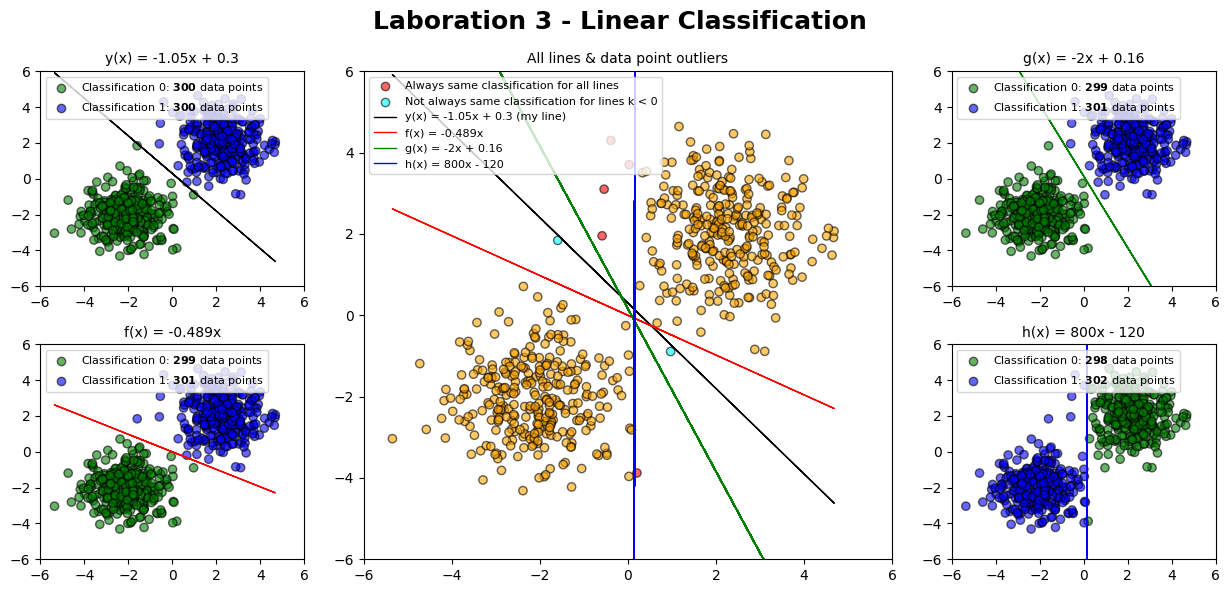

In [4]:
# Visa plottar
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from laboration_3_multi import y, line_yx, labelled_data_yx, plot_separate_line

line_comparison = pd.DataFrame({"y(x)": labelled_data_yx, "f(x)": labelled_data_fx, "g(x)": labelled_data_gx, "h(x)": labelled_data_hx})
yfg_lines_equal = line_comparison.iloc[:, :3].nunique(axis=1) == 1
all_lines_equal = line_comparison.nunique(axis=1) == 1

fig = plt.figure(figsize=(12.5,6))
grid_pos = gridspec.GridSpec(2, 3, width_ratios=[1,2,1], height_ratios=[1,1])
ax_left_top =       fig.add_subplot(grid_pos[0,0])
ax_left_bottom =    fig.add_subplot(grid_pos[1,0])
ax_center =         fig.add_subplot(grid_pos[:,1])
ax_right_top =      fig.add_subplot(grid_pos[0,2])
ax_right_bottom =   fig.add_subplot(grid_pos[1,2])

# Plot side plots (one line per plot)
plot_separate_line(x, y, line_comparison, "y(x)", line_yx, "black", "y(x) = -1.05x + 0.3", ax_left_top)
plot_separate_line(x, y, line_comparison, "f(x)", line_fx, "red", "f(x) = -0.489x", ax_left_bottom)
plot_separate_line(x, y, line_comparison, "g(x)", line_gx, "green", "g(x) = -2x + 0.16", ax_right_top)
plot_separate_line(x, y, line_comparison, "h(x)", line_hx, "blue", "h(x) = 800x - 120", ax_right_bottom)

# Plot main plot (all lines in one plot)
ax_center.scatter(x, y, edgecolors="black", alpha=0.6, color=["red" if same else ("orange" if yfg_same else "cyan") for same, yfg_same in zip(all_lines_equal, yfg_lines_equal)])
ax_center.scatter([], [], edgecolors="black", alpha=0.6, color="red", label="Always same classification for all lines")
ax_center.scatter([], [], edgecolors="black", alpha=0.6, color="cyan", label="Not always same classification for lines k < 0")
ax_center.plot(x, line_yx, color="black", label="y(x) = -1.05x + 0.3 (my line)", linewidth=1)
ax_center.plot(x, line_fx, color="red", label="f(x) = -0.489x", linewidth=1)
ax_center.plot(x, line_gx, color="green", label="g(x) = -2x + 0.16", linewidth=1)
ax_center.plot(x, line_hx, color="blue", label="h(x) = 800x - 120", linewidth=1)
ax_center.set_title("All lines & data point outliers", fontsize=10)
ax_center.set_ylim(-6,6)
ax_center.set_xlim(-6,6)
ax_center.legend(fontsize=8, loc="upper left")

plt.suptitle("Laboration 3 - Linear Classification", fontweight="bold", fontsize=18)
plt.tight_layout()
plt.show()

<span style="font-family: Calibri; font-size: 12pt">

### **Utvärdering & resonemang kring klassificeringarna**

Här ovanför visas samtliga linjer och dess respektive klassificerade punkter. Av utfallet att döma så har alla linjer i princip samma antal 0- och 1-klassificeringar. Den stora skillnaden är dock linje h(x) som är den enda linjen med ett positivt k-värde. Detta gör att den absoluta majoriteten av datapunkterna blir klassificerade precis tvärtom gentemot övriga linjers eftersom *"under"* linjen helt plötsligt blir till **höger** om den istället för till vänster. I och med att vi inte vet vad det är för typ av data vi klassificerar så är det svårt att säga exakt vad detta kan få för konsekvenser, men risken finns att denna linje felklassificerar nästan alla datapunkter. Är det t ex så att vi klassificerar patienter som sjuka eller icke-sjuka så kan det ju bli väldigt fel.

Om vi tittar på den stora plotten i mitten så kan vi se att jag har markerat några datapunkter med <font color="red">**rött**</font> och några med <font color="cyan">**turkos**</font>. Jag har valt att definiera dessa som relativa/kontextuella outliers eftersom de avviker i klassificeringen (och inte i form av extrema x- eller y-värden).

* De <font color="red">**röda**</font> punkterna får samma klassificering för **samtliga** linjer. Initialt så tänkte jag enligt följande gällande detta:
Förutsatt att en linjär klassificering är korrekt modell att använda för just den här datan samt att en av dessa fyra linjer är den mest lämpade, så borde det innebära att dessa punkter är de enda som garanterat får rätt klassificering. **Men**, att just den mest lämpade linjen är med här är dock inte säkert och förutsatt att den inte är det så säger inte denna företeelse oss någonting egentligen. Hade den "perfekta" linjen t ex gått mittemellan g(x) och h(x) (med ett negativt k-värde) så hade inte längre alla dessa punkter fått samma klassificering för samtliga linjer. Jag ansåg det dock värt att fundera över.
* De båda <font color="cyan">**turkosa**</font> punkterna är de som **inte** får samma klassificering för samtliga linjer **med ett negativt k-värde**, d.v.s. y(x), f(x) och g(x). På så sätt avviker även de från övriga punkter. Vad detta säger är att inte heller någon av dessa linjer går att lita på fullt ut.

Något jag tar upp här ovan är hur förutsättningarna förändras om vi exempelvis skulle lägga till en specifik linje. Eftersom antalet potentiella linjer mellan exempelvis linje f(x) och en tilltänkt linje med ett k-värde långt under 0 (t ex en spegelbild av linje h(x) med k = -800) kan vara oändliga så får det mig att fundera över hur lämplig denna klassifikationsmodell faktiskt är. Eller är det bara så att vi helt enkelt vet för lite för att kunna avgöra detta? 

Jag hade kunnat anta att min linje y(x) är den perfekta linjen och därefter göra en jämförelse och mäta noggrannhet gentemot övriga linjer, men det känns inte relevant då vi inte vet om min linje klassificerar bäst bara baserat på att den har exakt balans mellan antalet 0:or och 1:or. Vi vet som sagt inte ens om denna klassificeringsmodell är den som egentligen borde användas i det här fallet.

### **Avslutning**

Denna laboration har lyft fram väldigt många tankar och perspektiv, men få specifika slutsatser. Resonemangen har bollats fram och tillbaka, men har oftast landat i slutsatsen att **vi vet för lite** för att kunna avgöra vad som är bra eller dåligt med de olika linjerna samt med linjär klassificering som använd metod. Även om min linje är den som delar datapunkterna mest balanserat så behöver inte det betyda att den är den bästa att klassificera datan.

</span>